In [8]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.stats import linregress


In [ ]:
years = [2021.0, 2022.0, 2023.0]
boroughs = ['manhattan', 'brooklyn', 'bronx', 'queens']

borough_year_data = {}
for y in years:
    borough_year_data[y] = {}
    for b in boroughs:
        borough_year_data[y][b] = pd.read_csv(f"..\\Dataset\\NYC_DWT_Analysis\\{y}\\{b}.csv")

nta_gdf = gpd.read_file("..\\Dataset\\NYC_DWT_Analysis\\nynta2020_25d\\nynta2020.shp")
nta_gdf['NTA2020'] = nta_gdf["NTA2020"].astype(str).str.lower()

In [10]:
BOROUGH_COLORS = {
    "manhattan": "#e41a1c",
    "brooklyn":  "#377eb8",
    "bronx":     "#4daf4a",
    "queens":    "#ff7f00",
}

In [11]:
#NTA aggregation, just as before
nta_data = {}
for y in years:
    nta_data[y] = {}
    for b in boroughs:
        df = borough_year_data[y][b].copy()

        df["has_violation"] = (df["Violation_Code"] != '0').astype(int)
        df["is_audit"] = (df["Activity_Type"] == "nyc health department audit").astype(int)

        agg = df.groupby('NTA_Code').agg(   inspection_count = ("BIN", "count"),
                                            violation_count = ("has_violation", "sum"),
                                            total_dwt = ('Number of DWT', "sum"),
                                            audit_count = ("is_audit", "sum"), ).reset_index()

        agg["violation_rate"] = agg["violation_count"]/agg["inspection_count"]
        agg["avg_dwt"]        = agg["total_dwt"]/agg["inspection_count"]
        agg["audit_fraction"] = agg["audit_count"]/agg["inspection_count"]

        nta_data[y][b] = agg.drop(columns=["violation_count", "total_dwt", "audit_count"])

In [12]:
NTA_Prefix = {'bronx': 'bx', 'queens': 'qn', 'brooklyn': 'bk', 'manhattan': 'mn'}

geo_data = {}
for y in years:
    geo_data[y] = {}
    for b in boroughs:
        prefix = NTA_Prefix[b]
        borough_shape = nta_gdf[nta_gdf["NTA2020"].str.startswith(prefix)].copy()
        merged = borough_shape.merge(nta_data[y][b], left_on="NTA2020", right_on="NTA_Code", how="left")
        for col in ["inspection_count", "violation_rate", "avg_dwt", "audit_fraction"]:
            merged[col] = merged[col].fillna(0)
        geo_data[y][b] = merged.reset_index(drop=True)

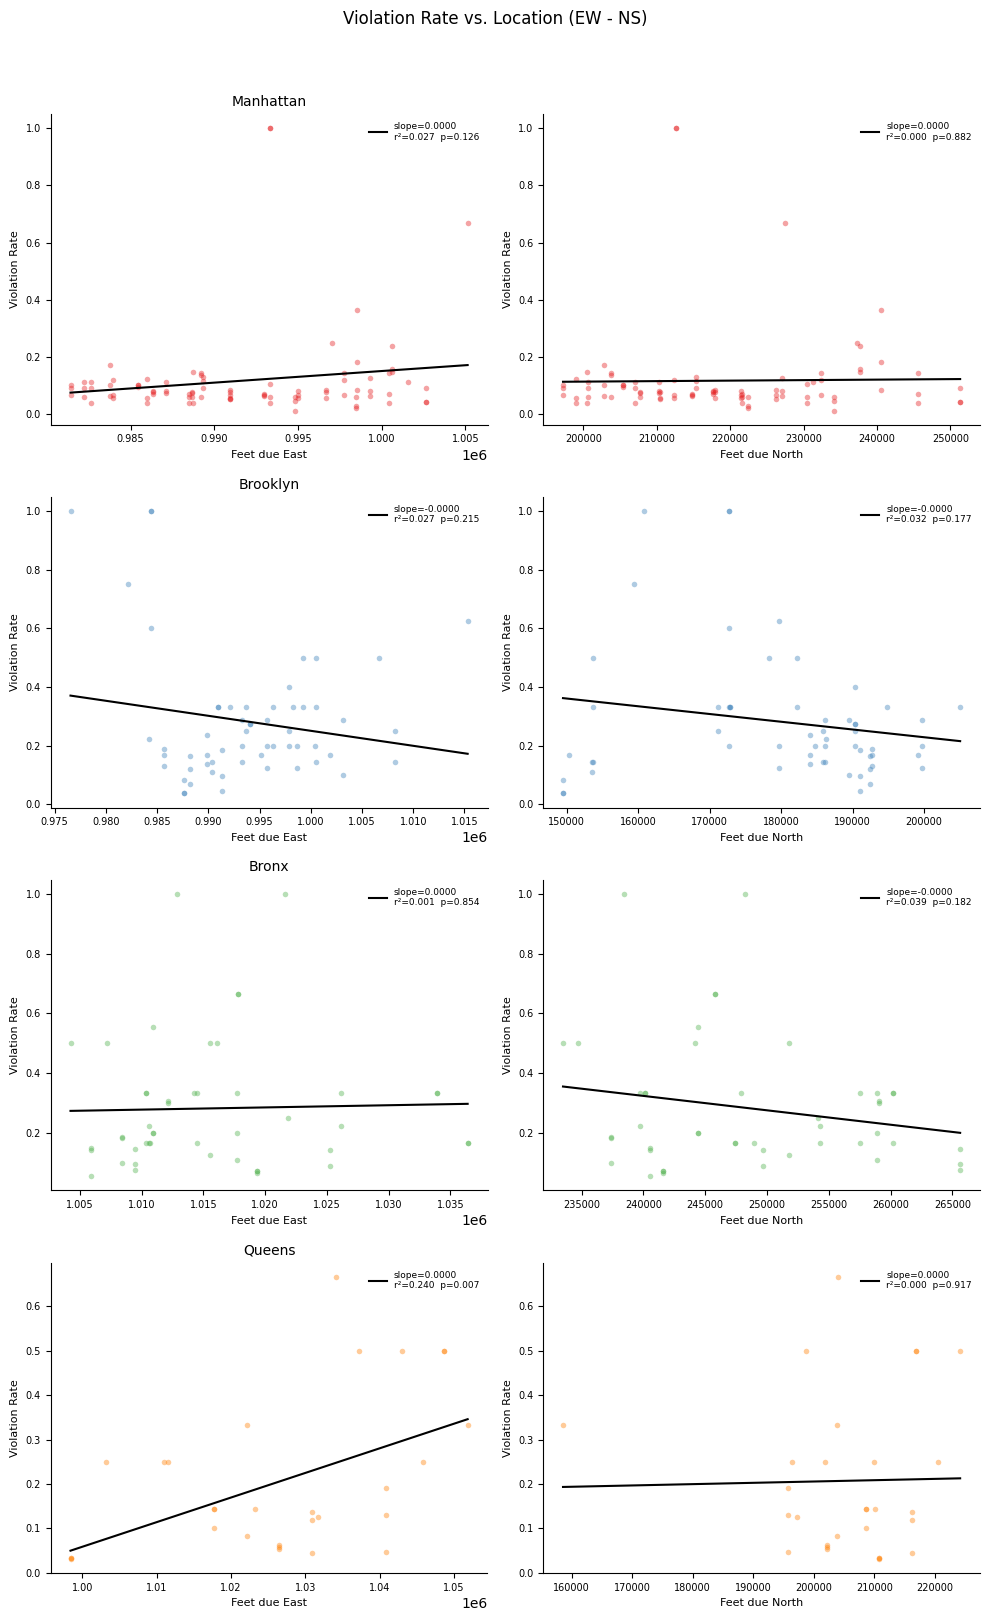

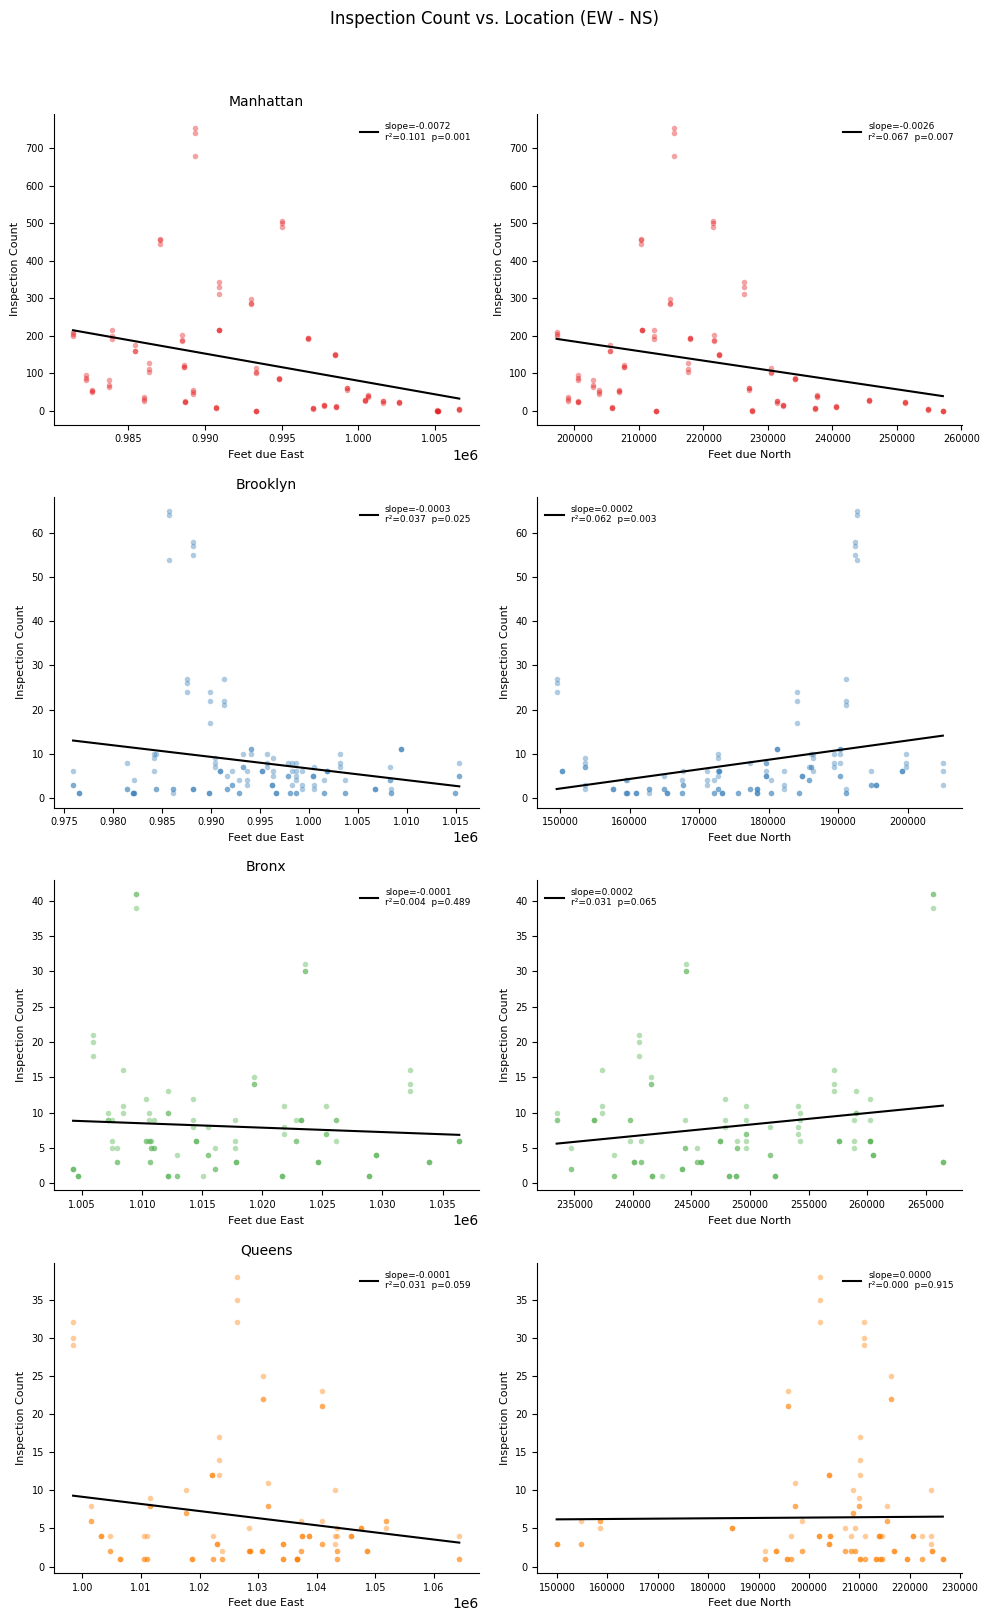

In [ ]:
# ── Task 3 · Plot 3: Variable vs. spatial coordinates (trend surface check) ──
# Plot violation_rate and inspection_count against NTA centroid
# The coordinates are measured in US Survey feet, not actual longitude or latitude
for var, label in [
    ("violation_rate",   "Violation Rate"),
    ("inspection_count", "Inspection Count"),
]:
    fig, axes = plt.subplots(
        len(boroughs), 2,
        figsize=(10, 4 * len(boroughs))
    )
    fig.suptitle(
        f"{label} vs. Location (EW - NS)\n",
        fontsize=12, y=1.01
    )

    for bi, b in enumerate(boroughs):
        lon_all, lat_all, val_all = [], [], []
        for y in years:
            gdf = geo_data[y][b].copy()
            gdf = gdf[gdf[var] > 0]
            lon_all.extend(gdf.geometry.centroid.x.values)
            lat_all.extend(gdf.geometry.centroid.y.values)
            val_all.extend(gdf[var].values)

        lon_all = np.array(lon_all)
        lat_all = np.array(lat_all)
        val_all = np.array(val_all)
        col = BOROUGH_COLORS[b]

        for ci, (coord, coord_label) in enumerate([
            (lon_all, "Feet due East"),
            (lat_all, "Feet due North"),
        ]):
            ax = axes[bi, ci]
            ax.scatter(coord, val_all, color=col, alpha=0.40, s=16, linewidths=0)

            slope, intercept, r, p, _ = linregress(coord, val_all)
            x_fit = np.linspace(coord.min(), coord.max(), 100)
            ax.plot( x_fit, slope * x_fit + intercept, color="black", linewidth=1.5, label=f"slope={slope:.4f}\nr²={r**2:.3f}  p={p:.3f}"
            )


            if ci == 0:
                ax.set_title(f"{b.capitalize()}", fontsize=10)
            ax.set_xlabel(coord_label, fontsize=8)
            ax.set_ylabel(label, fontsize=8)
            ax.legend(fontsize=6.5, frameon=False)
            ax.spines[["top", "right"]].set_visible(False)
            ax.tick_params(labelsize=7)

    plt.tight_layout()
    plt.show()

These trendlines describe the variation in inspection count and violation rate as NTAs move along the cardinal directions. A few insights include:
- A slight increase in inspections for all boroughs except Manhattan while moving north - indicating that the north of all boroughs are more policed than the south. This trend is reversed in Manhattan, though, aligning with south Manhattan being generally more affluent and sought-after.
- It is also true across all boroughs that the east is significantly more inspected than the west, which indicates that the EW trend in violation rate is likely random, as the trends are shallow and and thus more susceptible to changes in inspection count. 